In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [33]:
matches=pd.read_csv("stored_features/match_features_c_3_mu1_0.50_mu2_0.20.csv")
matches.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score', 'winner',
       'winner_code', 'home_neutral', 'home_ppg_last_5',
       'home_avg_goals_scored_last_5', 'home_avg_goals_conceded_last_5',
       'home_clean_sheets_rate_last_5', 'home_avg_goal_difference_last_5',
       'home_avg_goal_difference_last_10', 'home_failed_score_rate_last_5',
       'home_over_2_5_rate_last_5', 'home_over_3_5_rate_last_5',
       'home_under_1_5_rate_last_5', 'home_days_since_last_game',
       'home_pi_home_rating', 'home_pi_away_rating', 'home_pi_expected_gd',
       'home_pi_diff', 'away_ppg_last_5', 'away_avg_goals_scored_last_5',
       'away_avg_goals_conceded_last_5', 'away_clean_sheets_rate_last_5',
       'away_avg_goal_difference_last_5', 'away_avg_goal_difference_last_10',
       'away_failed_score_rate_last_5', 'away_over_2_5_rate_last_5',
       'away_over_3_5_rate_last_5', 'away_under_1_5_rate_last_5',
       'away_days_since_last_game', 'away_pi_home_rating',
       'away_

In [53]:
features = ['home_ppg_last_5',
       'home_avg_goals_scored_last_5', 'home_avg_goals_conceded_last_5',
       'home_clean_sheets_rate_last_5', 'home_avg_goal_difference_last_5',
       'home_avg_goal_difference_last_10', 'home_failed_score_rate_last_5',
       'home_over_2_5_rate_last_5', 'home_over_3_5_rate_last_5',
       'home_under_1_5_rate_last_5', 'home_days_since_last_game',
       'home_pi_home_rating', 'home_pi_away_rating', 'home_pi_expected_gd',
       'home_pi_diff', 'winner_code']
a_features = ['diff_ppg_last_5', 'diff_goal_difference',
       'diff_btts_rate', 'diff_avg_goals_scored_last_5',
       'diff_avg_goals_conceded_last_5', 'diff_over_2_5_rate',
       'diff_under_1_5_rate', 'diff_rests_days', 'winner_code']

home_feature_cols = [c for c in features if c != "winner_code"]
diff_feature_cols = [c for c in a_features if c != "winner_code"]

home_team_features = matches[home_feature_cols]
diff_features = matches[diff_feature_cols]

winner_code = matches["winner_code"]

In [55]:
home_team_features_scaled = pd.DataFrame(
    StandardScaler().fit_transform(home_team_features),
    columns=home_team_features.columns,
    index=home_team_features.index
)

diff_features_scaled = pd.DataFrame(
    StandardScaler().fit_transform(diff_features),
    columns=diff_features.columns,
    index=diff_features.index
)

home_team_features_scaled["winner_code"] = winner_code
diff_features_scaled["winner_code"] = winner_code

home_melted = pd.melt(
    home_team_features_scaled,
    id_vars=["winner_code"],
    value_vars=home_feature_cols,
    var_name="feature",
    value_name="value"
)

diff_melted = pd.melt(
    diff_features_scaled,
    id_vars=["winner_code"],
    value_vars=diff_feature_cols,
    var_name="feature",
    value_name="value"
)

In [56]:
label_map = {
    0: "Draw",
    1: "Home Win",
    2: "Away Win"
}

home_melted["result"] = home_melted["winner_code"].map(label_map)
diff_melted["result"] = diff_melted["winner_code"].map(label_map)

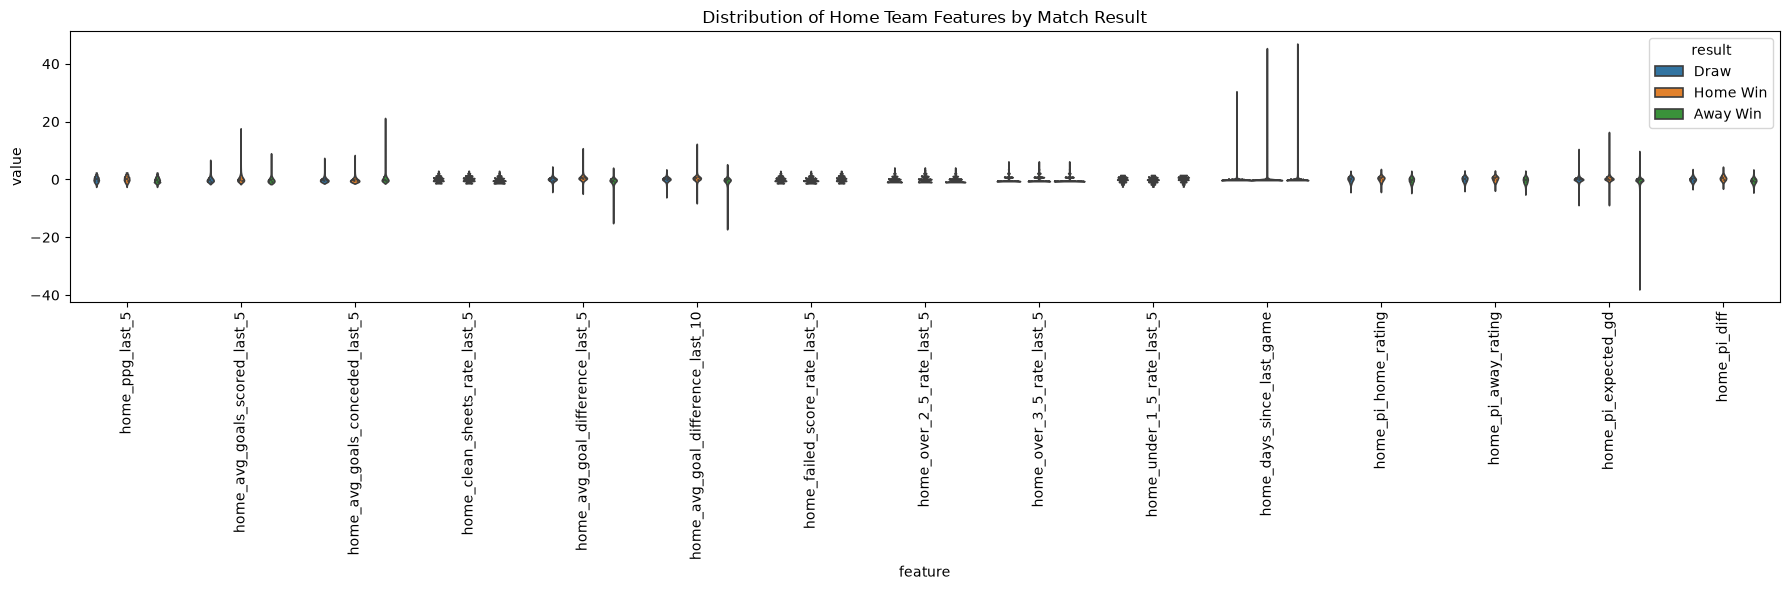

In [57]:
plt.figure(figsize=(18, 6))

sns.violinplot(
    data=home_melted,
    x="feature",
    y="value",
    hue="result",
    inner="quartile",
    palette="tab10",
    linewidth=1.2,
    cut=0
)

plt.xticks(rotation=90)
plt.title("Distribution of Home Team Features by Match Result")
plt.tight_layout()
plt.show()


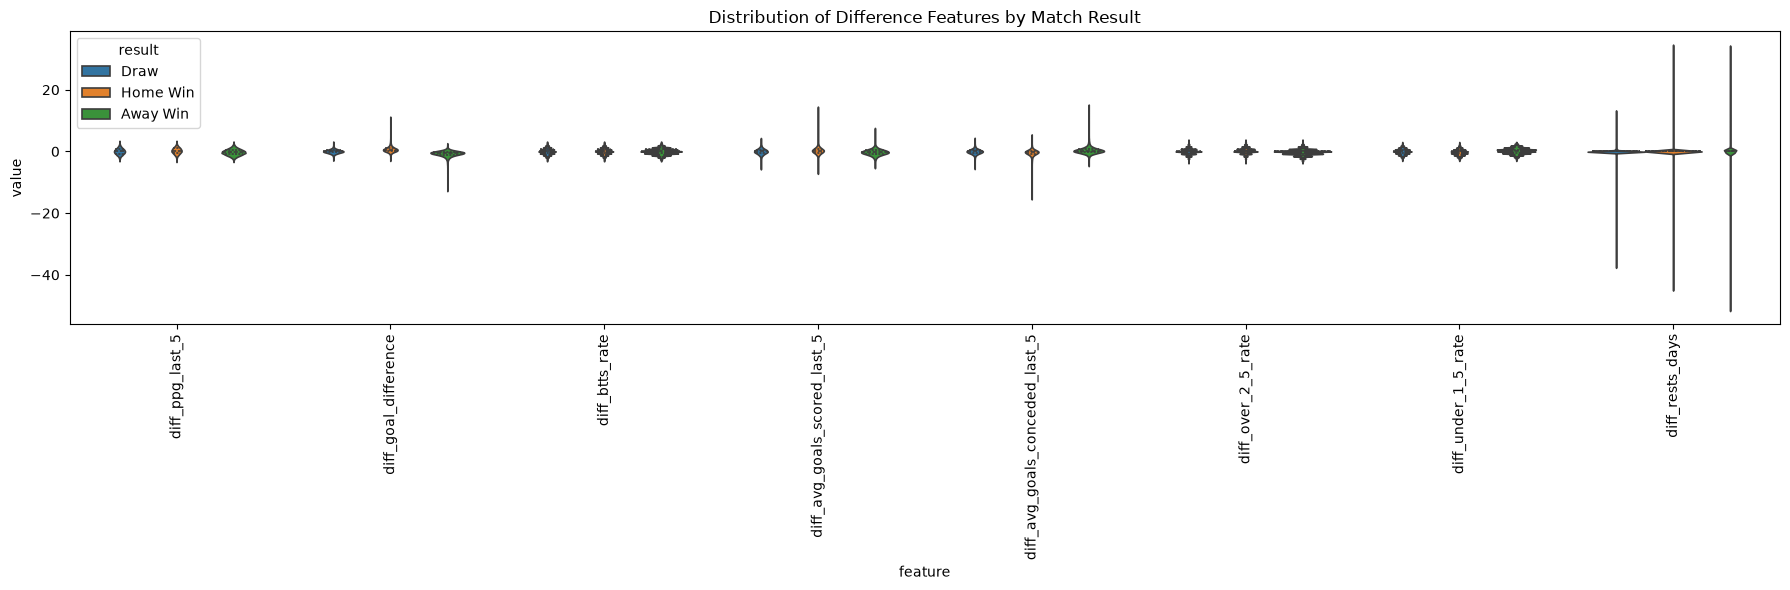

In [58]:
plt.figure(figsize=(18, 6))

sns.violinplot(
    data=diff_melted,
    x="feature",
    y="value",
    hue="result",
    inner="quartile",
    palette="tab10",
    linewidth=1.2,
    cut=0
)

plt.xticks(rotation=90)
plt.title("Distribution of Difference Features by Match Result")
plt.tight_layout()
plt.show()

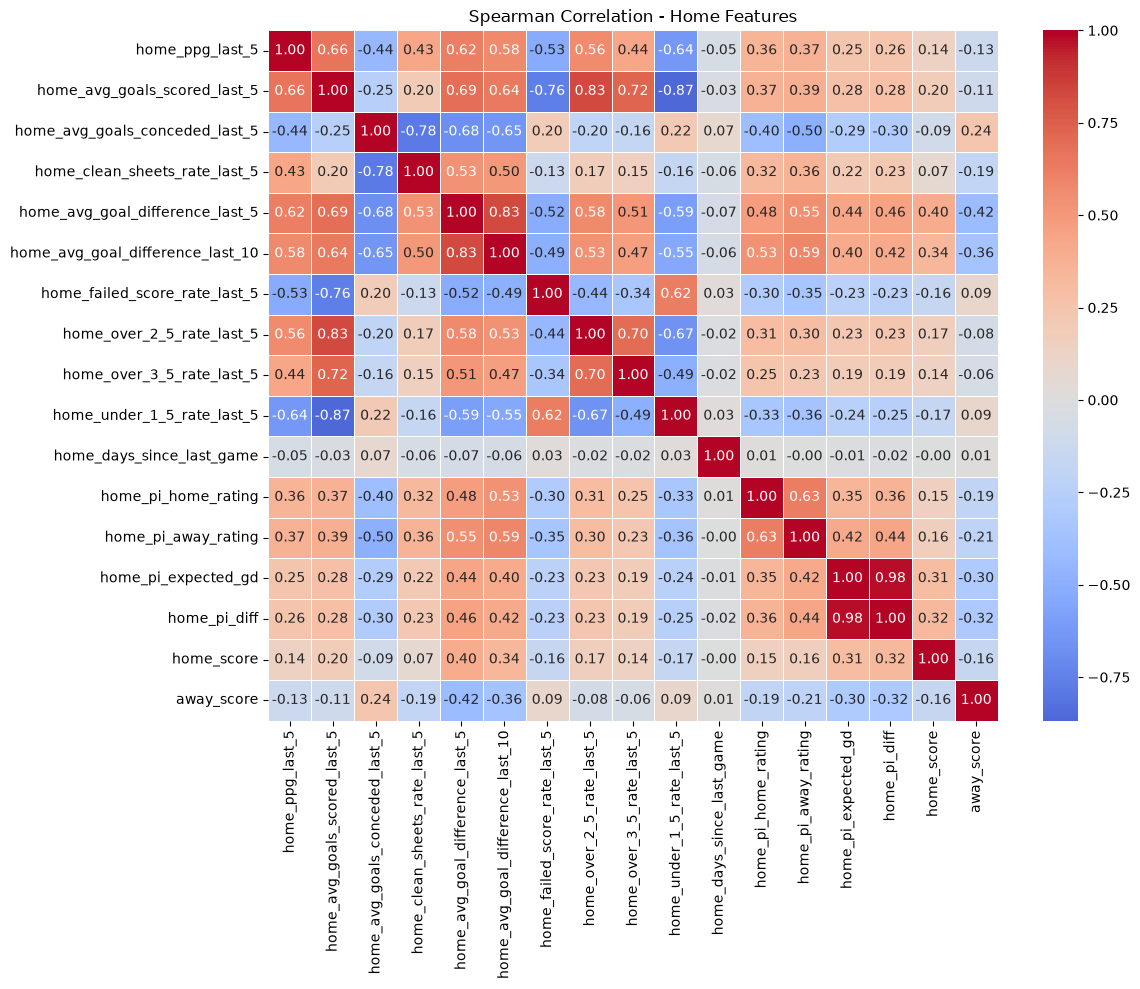

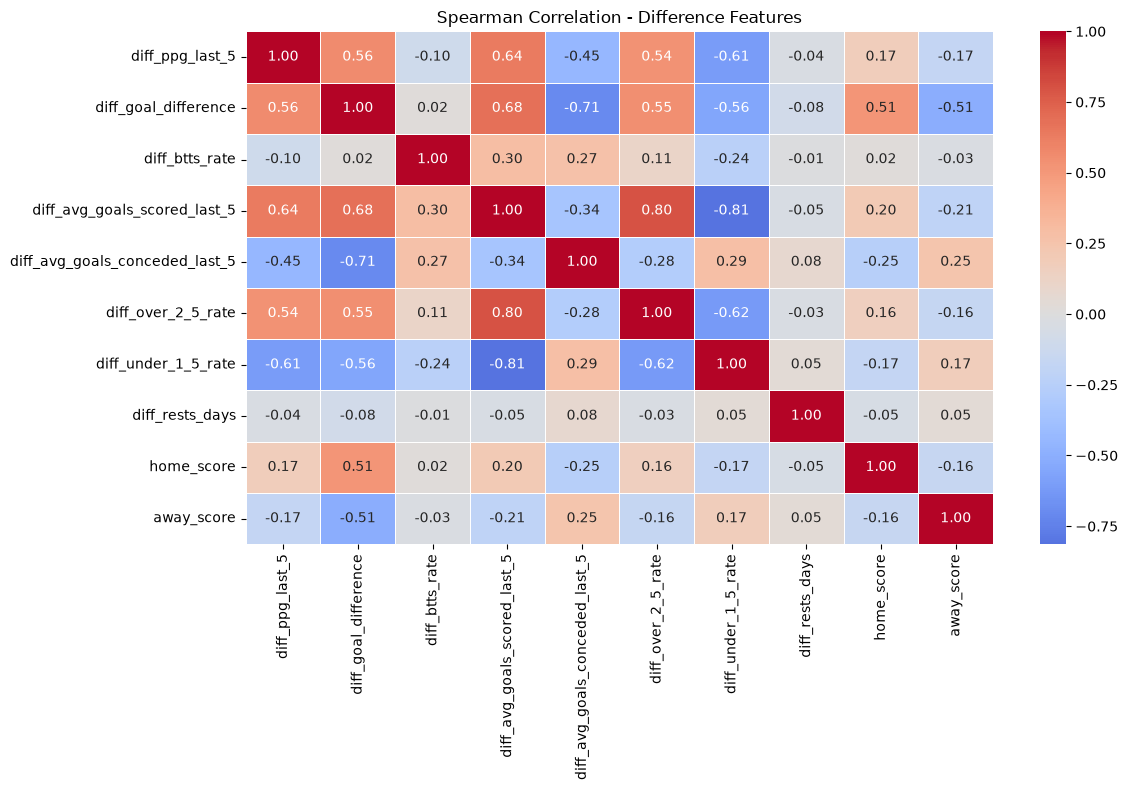

In [59]:
home_corr_cols = home_feature_cols + ["home_score", "away_score"]

home_corr = matches[home_corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(
    home_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Spearman Correlation - Home Features")
plt.tight_layout()
plt.show()


diff_corr_cols = diff_feature_cols + ["home_score", "away_score"]

diff_corr = matches[diff_corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(
    diff_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Spearman Correlation - Difference Features")
plt.tight_layout()
plt.show()

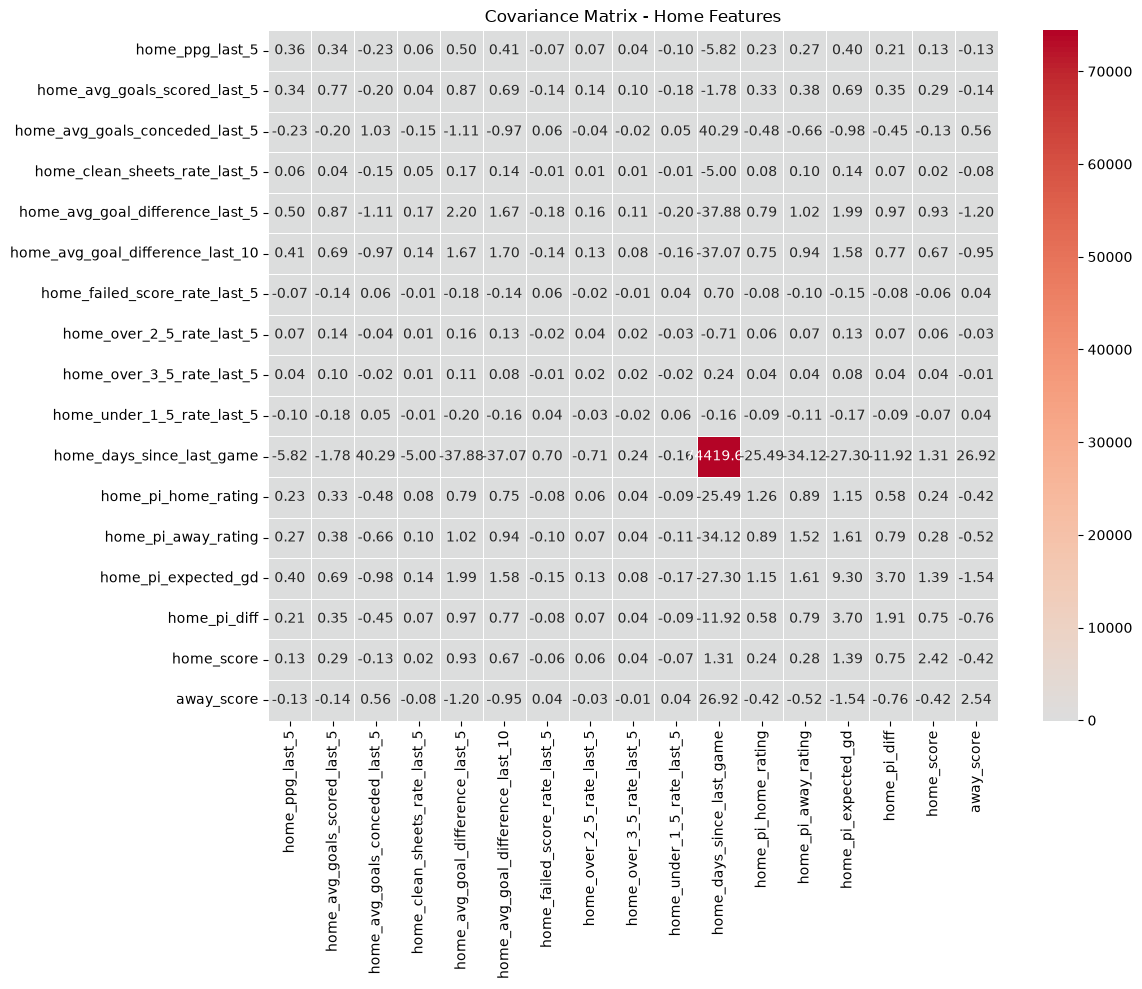

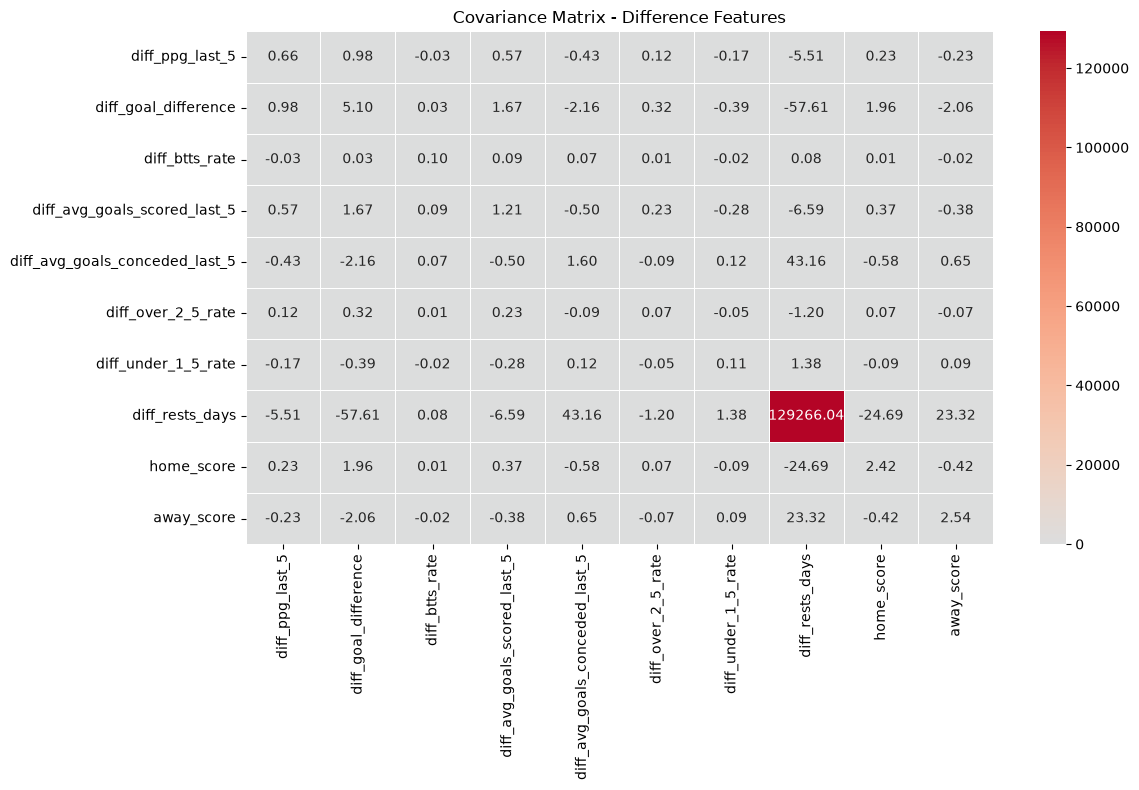

In [60]:
home_cov = matches[home_corr_cols].cov()

plt.figure(figsize=(12, 10))
sns.heatmap(
    home_cov,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Covariance Matrix - Home Features")
plt.tight_layout()
plt.show()


diff_cov = matches[diff_corr_cols].cov()

plt.figure(figsize=(12, 8))
sns.heatmap(
    diff_cov,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Covariance Matrix - Difference Features")
plt.tight_layout()
plt.show()